In [1]:
PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"  
OUTPUT_DIR = "/kaggle/working/"

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
warnings.filterwarnings('ignore')
 
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
all_results = []
 
print("Imports loaded!")

Using device: cuda
Imports loaded!


In [3]:
en_train = pd.read_csv(f"{PREPROCESSED_DIR}/en_train.csv")
en_val = pd.read_csv(f"{PREPROCESSED_DIR}/en_val.csv")
en_test = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")
 
bn_train = pd.read_csv(f"{PREPROCESSED_DIR}/bn_train.csv")
bn_val = pd.read_csv(f"{PREPROCESSED_DIR}/bn_val.csv")
bn_test = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")
 
# Fill any NaN in text_clean
for df in [en_train, en_val, en_test, bn_train, bn_val, bn_test]:
    df['text_clean'] = df['text_clean'].fillna('')
 
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
 
print(f"English: Train={len(en_train):,}, Val={len(en_val):,}, Test={len(en_test):,}")
print(f"Bangla:  Train={len(bn_train):,}, Val={len(bn_val):,}, Test={len(bn_test):,}")

English: Train=83,455, Val=10,432, Test=10,432
Bangla:  Train=67,009, Val=8,376, Test=8,377


In [4]:
all_results = []  # Store all results for comparison
 
def evaluate_model(model_name, y_true, y_pred, dataset_name, save_cm=True):
    """Evaluate and print metrics, save to results list."""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    report = classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values()),
                                   output_dict=True)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))
    
    # Confusion Matrix
    if save_cm:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CLASS_NAMES.values(),
                    yticklabels=CLASS_NAMES.values(), ax=ax)
        ax.set_title(f'{model_name} - {dataset_name}')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')
        plt.tight_layout()
        safe_name = f"{model_name}_{dataset_name}".replace(' ', '_').replace('/', '_')
        plt.savefig(f"{OUTPUT_DIR}cm_{safe_name}.png", dpi=100)
        plt.show()
    
    # Store results
    result = {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': round(acc, 4),
        'macro_f1': round(f1_macro, 4),
    }
    for cls_name in CLASS_NAMES.values():
        if cls_name in report:
            result[f'{cls_name}_precision'] = round(report[cls_name]['precision'], 4)
            result[f'{cls_name}_recall'] = round(report[cls_name]['recall'], 4)
            result[f'{cls_name}_f1'] = round(report[cls_name]['f1-score'], 4)
    
    all_results.append(result)
    return result

In [5]:
# ============================================================
# Simple word-level tokenizer
# ============================================================
class SimpleTokenizer:
    def __init__(self, max_vocab=30000):
        self.max_vocab = max_vocab
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
    
    def fit(self, texts):
        from collections import Counter
        word_counts = Counter()
        for text in texts:
            word_counts.update(str(text).split())
        
        for word, _ in word_counts.most_common(self.max_vocab - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        
        print(f"Vocabulary size: {len(self.word2idx)}")
        return self
    
    def encode(self, text, max_len=128):
        tokens = [self.word2idx.get(w, 1) for w in str(text).split()]
        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        return tokens
 
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        tokens = self.tokenizer.encode(self.texts[idx], self.max_len)
        return torch.tensor(tokens, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)
 
def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)

In [9]:
# ============================================================
# Extract labels from dataframes
# ============================================================
y_en_train = en_train['class'].values
y_en_val   = en_val['class'].values
y_en_test  = en_test['class'].values

y_bn_train = bn_train['label'].values
y_bn_val   = bn_val['label'].values
y_bn_test  = bn_test['label'].values

print("English train labels:", y_en_train.shape, "| Classes:", np.unique(y_en_train))
print("Bangla  train labels:", y_bn_train.shape, "| Classes:", np.unique(y_bn_train))

English train labels: (83455,) | Classes: [0 1 2]
Bangla  train labels: (67009,) | Classes: [0 1 2]


In [13]:
!pip install transformers datasets accelerate -q
 
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset as HFDataset
import gc

In [14]:

def train_transformer(model_name_hf, train_texts, train_labels, val_texts, val_labels,
                      display_name, dataset_name, epochs=3, batch_size=32, max_len=128,
                      class_weights_list=None):
    """Train and evaluate a Hugging Face transformer model."""
    
    print(f"\n{'='*60}")
    print(f"Training {display_name} on {dataset_name}...")
    print(f"{'='*60}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name_hf)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_hf, num_labels=3, ignore_mismatched_sizes=True
    )
    
    # Tokenize
    train_encodings = tokenizer(list(train_texts), truncation=True, padding=True,
                                 max_length=max_len, return_tensors='pt')
    val_encodings = tokenizer(list(val_texts), truncation=True, padding=True,
                               max_length=max_len, return_tensors='pt')
    
    class TransformerDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels
        def __len__(self):
            return len(self.labels)
        def __getitem__(self, idx):
            item = {k: v[idx] for k, v in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
            return item
    
    train_dataset = TransformerDataset(train_encodings, list(train_labels))
    val_dataset = TransformerDataset(val_encodings, list(val_labels))
    
    # Custom trainer with class weights
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            if class_weights_list is not None:
                weight = torch.tensor(class_weights_list, dtype=torch.float).to(logits.device)
                loss = nn.CrossEntropyLoss(weight=weight)(logits, labels)
            else:
                loss = nn.CrossEntropyLoss()(logits, labels)
            return (loss, outputs) if return_outputs else loss
    
    training_args = TrainingArguments(
        output_dir=f'{OUTPUT_DIR}transformer_{dataset_name}',
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir=f'{OUTPUT_DIR}logs',
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="none",
        fp16=torch.cuda.is_available(),
    )
    
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )
    
    trainer.train()
    
    # Predict
    predictions = trainer.predict(val_dataset)
    preds = predictions.predictions.argmax(axis=1)
    
    # Also get probabilities (needed for Phase 4 & 5)
    probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=1).numpy()
    
    evaluate_model(display_name, val_labels, preds, dataset_name)
    
    # Save model and probabilities
    model.save_pretrained(f"{OUTPUT_DIR}{display_name.replace(' ', '_').replace('/', '_')}_{dataset_name}")
    tokenizer.save_pretrained(f"{OUTPUT_DIR}{display_name.replace(' ', '_').replace('/', '_')}_{dataset_name}")
    np.save(f"{OUTPUT_DIR}val_probs_{display_name.replace(' ', '_')}_{dataset_name}.npy", probs)
    np.save(f"{OUTPUT_DIR}val_preds_{display_name.replace(' ', '_')}_{dataset_name}.npy", preds)
    
    # Cleanup
    del model, trainer, train_dataset, val_dataset
    gc.collect()
    torch.cuda.empty_cache()
    
    return preds, probs


Training BERT on English...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


BERT - English
Accuracy: 0.8957
Macro F1: 0.8954
              precision    recall  f1-score   support

 Non-hateful       0.87      0.85      0.86      3470
     Hateful       0.91      0.93      0.92      3485
   Sarcastic       0.91      0.91      0.91      3477

    accuracy                           0.90     10432
   macro avg       0.90      0.90      0.90     10432
weighted avg       0.90      0.90      0.90     10432



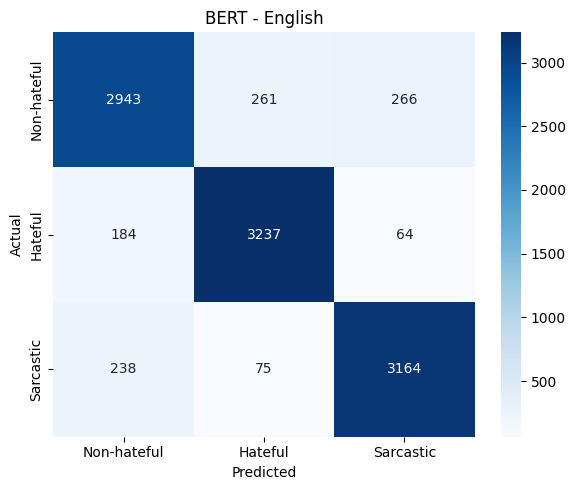

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
# ============================================================
# 3C.1: ENGLISH TRANSFORMERS
# ============================================================
 
# BERT
bert_en_preds, bert_en_probs = train_transformer(
    "bert-base-uncased",
    en_train['text_clean'].values, y_en_train,
    en_val['text_clean'].values, y_en_val,
    "BERT", "English", epochs=3, batch_size=32
)



Training DistilBERT on English...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



DistilBERT - English
Accuracy: 0.8877
Macro F1: 0.8878
              precision    recall  f1-score   support

 Non-hateful       0.85      0.86      0.85      3470
     Hateful       0.93      0.90      0.92      3485
   Sarcastic       0.89      0.90      0.90      3477

    accuracy                           0.89     10432
   macro avg       0.89      0.89      0.89     10432
weighted avg       0.89      0.89      0.89     10432



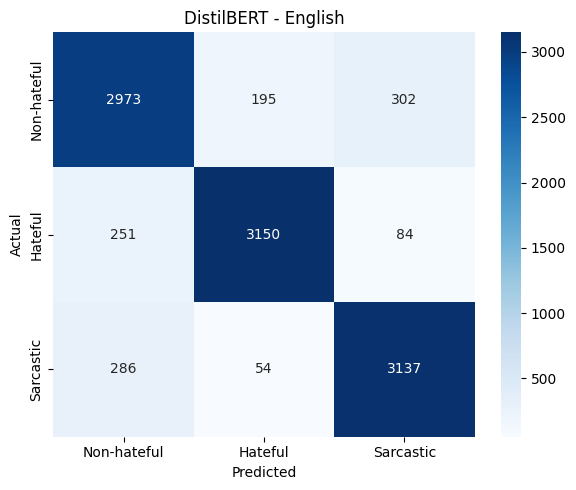

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
# DistilBERT (lighter, faster)
distilbert_en_preds, distilbert_en_probs = train_transformer(
    "distilbert-base-uncased",
    en_train['text_clean'].values, y_en_train,
    en_val['text_clean'].values, y_en_val,
    "DistilBERT", "English", epochs=3, batch_size=64
)